In [2]:
!pip install torcheval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 6.3 MB/s eta 0:00:00


In [4]:
from google.colab import files
uploaded = files.upload()

Saving cnn_model.py to cnn_model.py
Saving dnn_model.py to dnn_model.py
Saving resnet_model.py to resnet_model.py
Saving vgg_model.py to vgg_model.py


Training DNN on cpu

Epoch 1/15 | Train Acc: 82.76% | Val Acc: 91.70% | Val F1: 0.9172 | Val AUC: 0.9943 | Time: 15.8s
Epoch 2/15 | Train Acc: 91.65% | Val Acc: 93.71% | Val F1: 0.9364 | Val AUC: 0.9967 | Time: 15.8s
Epoch 3/15 | Train Acc: 93.36% | Val Acc: 94.68% | Val F1: 0.9474 | Val AUC: 0.9977 | Time: 16.7s
Epoch 4/15 | Train Acc: 94.12% | Val Acc: 95.31% | Val F1: 0.9522 | Val AUC: 0.9981 | Time: 15.9s
Epoch 5/15 | Train Acc: 94.57% | Val Acc: 95.90% | Val F1: 0.9588 | Val AUC: 0.9985 | Time: 15.7s
Epoch 6/15 | Train Acc: 95.18% | Val Acc: 95.95% | Val F1: 0.9593 | Val AUC: 0.9985 | Time: 16.4s
Epoch 7/15 | Train Acc: 95.34% | Val Acc: 96.34% | Val F1: 0.9638 | Val AUC: 0.9987 | Time: 15.9s
Epoch 8/15 | Train Acc: 95.55% | Val Acc: 96.43% | Val F1: 0.9647 | Val AUC: 0.9989 | Time: 15.7s
Epoch 9/15 | Train Acc: 95.55% | Val Acc: 96.51% | Val F1: 0.9655 | Val AUC: 0.9990 | Time: 15.7s
Epoch 10/15 | Train Acc: 95.82% | Val Acc: 96.33% | Val F1: 0.9630 | Val AUC: 0.9989 | Time: 16.5

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cleaned up temporary files for DNN



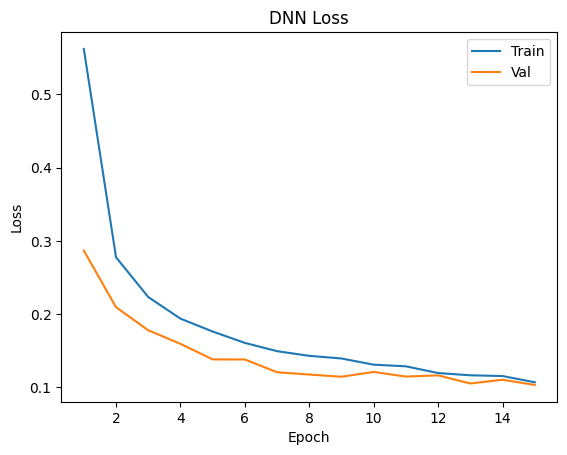

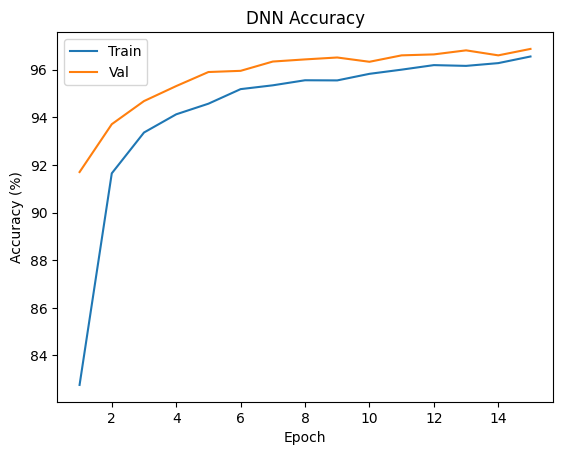

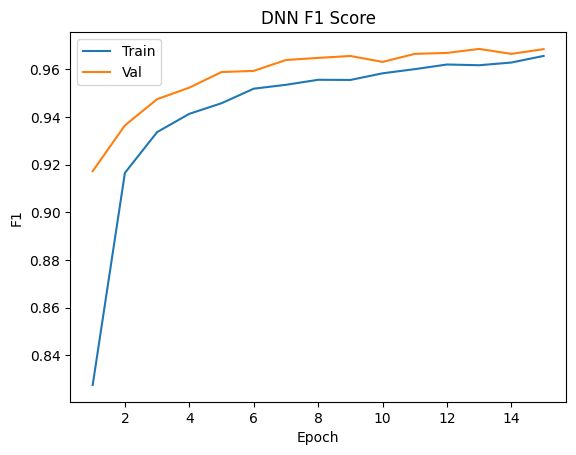

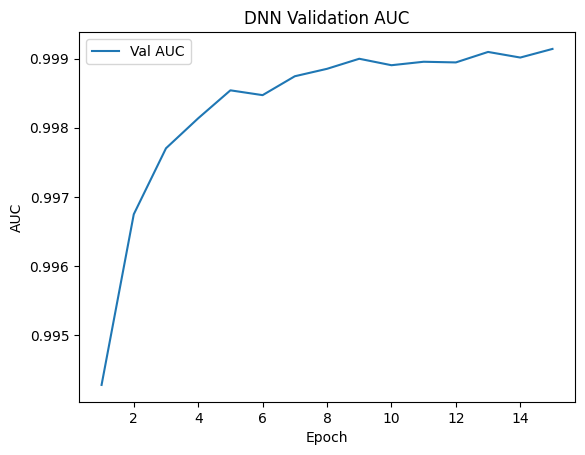

In [6]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import roc_auc_score
from torcheval.metrics.functional import multiclass_f1_score
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import time
from google.colab import files
import shutil
import os

# SELECT MODEL HERE

MODEL_NAME = "dnn"   # choose: "dnn", "cnn", "vgg", "resnet"
LR = 1e-3
EPOCHS = 15
BATCH_SIZE = 128
# --------------------------

# Import models
from dnn_model import DNNModel
from cnn_model import CNNModel
from vgg_model import VGGModel
from resnet_model import ResNetModel


def train_one_epoch(model, loss_fn, optimizer, device, dataloader):
    model.train()
    total_loss, correct, f1_scores = 0, 0, []

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        f1 = multiclass_f1_score(preds, labels, num_classes=10)
        f1_scores.append(f1.item())

    avg_loss = total_loss / len(dataloader)
    accuracy = 100.0 * correct / len(dataloader.dataset)
    avg_f1 = np.mean(f1_scores)
    return avg_loss, accuracy, avg_f1


def evaluate(model, loss_fn, device, dataloader):
    model.eval()
    total_loss, correct = 0, 0
    f1_scores, auc_scores = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()

            f1 = multiclass_f1_score(preds, labels, num_classes=10)
            f1_scores.append(f1.item())

            probs = F.softmax(outputs, dim=1).cpu().numpy()
            try:
                auc = roc_auc_score(labels.cpu().numpy(), probs, multi_class="ovr")
                auc_scores.append(auc)
            except Exception:
                pass

    avg_loss = total_loss / len(dataloader)
    accuracy = 100.0 * correct / len(dataloader.dataset)
    avg_f1 = np.mean(f1_scores)
    avg_auc = np.mean(auc_scores) if auc_scores else 0.0
    return avg_loss, accuracy, avg_f1, avg_auc


def main(model_name, lr, epochs, batch_size):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training {model_name.upper()} on {device}\n")

    # Model selection
    if model_name == "dnn":
        model = DNNModel()
    elif model_name == "cnn":
        model = CNNModel()
    elif model_name == "vgg":
        model = VGGModel()
    elif model_name == "resnet":
        model = ResNetModel()
    else:
        raise ValueError("Invalid model name")

    model.to(device)

    # Directory for results
    model_dir = f"./results_{model_name}/"
    Path(model_dir).mkdir(parents=True, exist_ok=True)

    # Reproducibility
    torch.manual_seed(42)

    # Resize only for ResNet
    resize_size = (32, 32) if model_name == "resnet" else (28, 28)

    transform = transforms.Compose([
        transforms.Resize(resize_size),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    dataset = datasets.MNIST("../data", train=True, download=True, transform=transform)
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [50000, 10000])
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    train_f1s, val_f1s, val_aucs = [], [], []
    best_f1 = 0
    best_model_path = f"{model_dir}best_model.pth"

    # Training loop
    for epoch in range(1, epochs + 1):
        start_time = time.time()

        train_loss, train_acc, train_f1 = train_one_epoch(model, loss_fn, optimizer, device, train_loader)
        val_loss, val_acc, val_f1, val_auc = evaluate(model, loss_fn, device, val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)
        val_aucs.append(val_auc)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), best_model_path)

        duration = time.time() - start_time
        print(f"Epoch {epoch}/{epochs} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% "
              f"| Val F1: {val_f1:.4f} | Val AUC: {val_auc:.4f} | Time: {duration:.1f}s")

    # Plot and save results
    epochs_arr = np.arange(1, epochs + 1)

    def save_plot(values1, values2, title, ylabel, filename):
        plt.figure()
        plt.plot(epochs_arr, values1, label="Train")
        plt.plot(epochs_arr, values2, label="Val")
        plt.title(f"{model_name.upper()} {title}")
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.legend()
        plt.savefig(f"{model_dir}{filename}")

    save_plot(train_losses, val_losses, "Loss", "Loss", "loss_plot.png")
    save_plot(train_accs, val_accs, "Accuracy", "Accuracy (%)", "accuracy_plot.png")
    save_plot(train_f1s, val_f1s, "F1 Score", "F1", "f1_plot.png")
    plt.figure()
    plt.plot(epochs_arr, val_aucs, label="Val AUC")
    plt.title(f"{model_name.upper()} Validation AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()
    plt.savefig(f"{model_dir}auc_plot.png")

    print(f"\nTraining complete. Best model saved to: {best_model_path}")

    # Zip and auto-download
    zip_name = f"results_{model_name}.zip"
    os.system(f"zip -r {zip_name} {model_dir} > /dev/null")
    files.download(zip_name)
    print(f"Downloading {zip_name} ...")

    # Clean up (optional)
    shutil.rmtree(model_dir, ignore_errors=True)
    if os.path.exists(zip_name):
        print(f"Cleaned up temporary files for {model_name.upper()}\n")


# Execute
main(MODEL_NAME, LR, EPOCHS, BATCH_SIZE)
